In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [2]:
df = pd.read_csv('Android_Ransomeware.csv')
df.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,151054,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,1,172.217.2.174-10.42.0.211-443-51023-6,10.42.0.211,51023,172.217.2.174,443,6,16/06/2017 03:55:47,349,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,2,172.217.12.174-10.42.0.211-443-34259-6,10.42.0.211,34259,172.217.12.174,443,6,16/06/2017 03:55:52,119,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,3,172.217.10.74-10.42.0.211-443-55509-6,10.42.0.211,55509,172.217.10.74,443,6,16/06/2017 03:55:53,37055,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,4,172.217.2.174-10.42.0.211-443-44852-6,10.42.0.211,44852,172.217.2.174,443,6,16/06/2017 03:55:58,178727,6,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [3]:
df.shape

(392034, 86)

In [4]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]


num_col = df.select_dtypes(include=['float64', 'int64']).columns
cat_col = df.select_dtypes(include=['object']).columns

df[num_col] = df[num_col].fillna(df[num_col].median())
df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])

print(missing_values.sum())


0


In [5]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)
df.dropna(inplace=True)

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])
df[cat_cols] = df[cat_cols].astype(str)

scaler = StandardScaler()
encoder = LabelEncoder()

df[num_cols] = scaler.fit_transform(df[num_cols])
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)
df.head()

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,-1.298572,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.479042,-0.032246,...,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464,Benign
1,-1.297878,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.485900,-0.151883,...,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464,Benign
2,-1.297185,148227,14,-0.238766,1294,-0.358896,-0.515637,7,-0.485911,-0.151883,...,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464,Benign
3,-1.296491,142970,14,0.903302,1247,-0.358896,-0.515637,8,-0.484230,-0.181792,...,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464,Benign
4,-1.295797,151270,14,0.330548,1328,-0.358896,-0.515637,9,-0.477782,-0.032246,...,0.002823,-0.165348,-0.057794,-0.15016,-0.16169,-0.306584,-0.11614,-0.31154,-0.295464,Benign


In [6]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.479042,-0.032246,-0.008793,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
1,151298,14,0.662205,1328,-0.358896,-0.515637,4,-0.485900,-0.151883,-0.107620,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
2,148227,14,-0.238766,1294,-0.358896,-0.515637,7,-0.485911,-0.151883,-0.107620,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
3,142970,14,0.903302,1247,-0.358896,-0.515637,8,-0.484230,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
4,151270,14,0.330548,1328,-0.358896,-0.515637,9,-0.477782,-0.032246,-0.021147,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
392029,26058,13,0.814087,19,-0.384353,1.874255,27131,-0.484792,-0.181792,-0.095267,...,0.002826,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392030,53062,13,-0.222643,4986,-0.379784,1.874255,27059,-0.482212,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392031,15022,13,-0.834362,19,-0.384353,1.874255,27064,-0.483113,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker
392032,17539,13,-0.445790,19,-0.384353,1.874255,27120,-0.484786,-0.181792,-0.095267,...,0.002823,-0.165348,-0.057794,-0.150160,-0.161690,-0.306584,-0.11614,-0.31154,-0.295464,WannaLocker


In [7]:
df['Label'].value_counts()

Label
SVpeng         54161
PornDroid      46082
Koler          44555
Benign         43091
RansomBO       39859
Charger        39551
Simplocker     36340
WannaLocker    32701
Jisut          25672
Lockerpin      25307
Pletor          4715
Name: count, dtype: int64

In [8]:
df1 = df.copy() #For binary classification
df2 = df.copy() #For Multiclass classification


In [9]:
df1['Label'] = df1['Label'].apply(lambda x: 'Benign' if x == 'Benign' else 'Ransomware')
print(df1['Label'].value_counts())

Label
Ransomware    348943
Benign         43091
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X = df1.drop(columns=['Label'])
y = df1['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"y train shape size: {y_train.shape}")

y train shape size: (274423,)


Accuracy:  100.0%
Precision: 100.0%
Recall:    100.0%
F1 Score:  100.0%


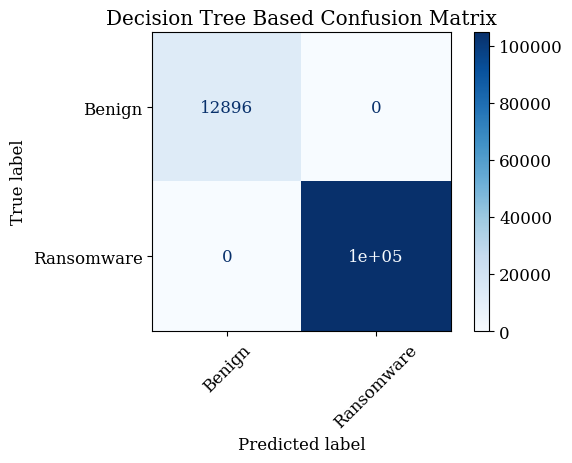

In [11]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay 
)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred1 = dt.predict(X_test)

accuracy = accuracy_score(y_test, pred1)
precision = precision_score(y_test, pred1, average='weighted', zero_division=0)
recall = recall_score(y_test, pred1, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred1, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy*100:.1f}%")
print(f"Precision: {precision*100:.1f}%")
print(f"Recall:    {recall*100:.1f}%")
print(f"F1 Score:  {f1*100:.1f}%")

cm = confusion_matrix(y_test, pred1)
ConfusionMatrixDisplay(cm, display_labels=dt.classes_).plot(cmap="Blues", xticks_rotation=45)
plt.title("Decision Tree Based Confusion Matrix")
plt.tight_layout()
plt.show()


In [12]:
print(classification_report(y_test, pred1, zero_division=0, digits=3))

              precision    recall  f1-score   support

      Benign      1.000     1.000     1.000     12896
  Ransomware      1.000     1.000     1.000    104715

    accuracy                          1.000    117611
   macro avg      1.000     1.000     1.000    117611
weighted avg      1.000     1.000     1.000    117611



Accuracy:  99.957%
Precision: 99.957%
Recall:    99.957%
F1 Score:  99.957%


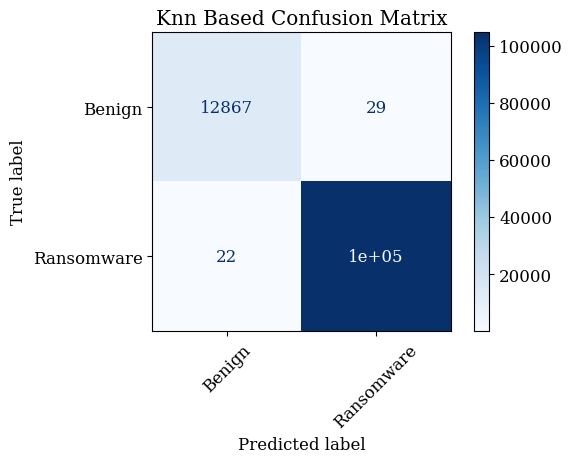

In [13]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

pred2 = knn.predict(X_test)
accuracy = accuracy_score(y_test, pred2)
precision = precision_score(y_test, pred2, average='weighted', zero_division=0)
recall = recall_score(y_test, pred2, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred2, average='weighted', zero_division=0)


print(f"Accuracy:  {accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")

cm  = confusion_matrix(y_test, pred2)
ConfusionMatrixDisplay(cm, display_labels=knn.classes_).plot(cmap='Blues', xticks_rotation=45)
plt.title("Knn Based Confusion Matrix")
plt.tight_layout()
plt.show()

In [14]:
print(classification_report(y_test, pred2, zero_division=0, digits=5))

              precision    recall  f1-score   support

      Benign    0.99829   0.99775   0.99802     12896
  Ransomware    0.99972   0.99979   0.99976    104715

    accuracy                        0.99957    117611
   macro avg    0.99901   0.99877   0.99889    117611
weighted avg    0.99957   0.99957   0.99957    117611



Accuracy:  96.091%
Precision: 95.967%
Recall:    96.091%
F1 Score:  95.872%


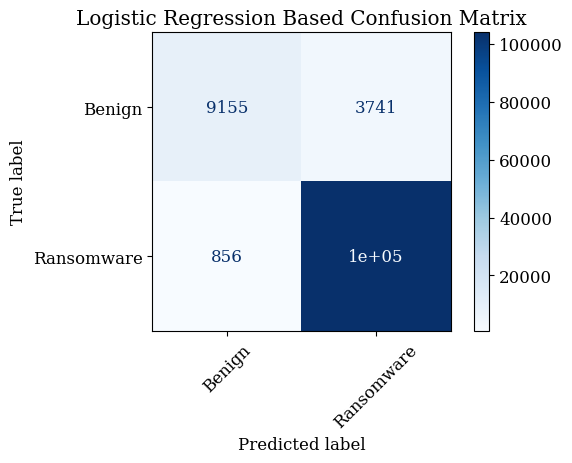

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)
lr.fit(X_train, y_train)
pred3 = lr.predict(X_test)

accuracy = accuracy_score(y_test, pred3)
precision = precision_score(y_test, pred3, average='weighted', zero_division=0)
recall = recall_score(y_test, pred3, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred3, average='weighted', zero_division=0)


print(f"Accuracy:  {accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")


cm = confusion_matrix(y_test, pred3)
ConfusionMatrixDisplay(cm, display_labels=lr.classes_).plot(cmap='Blues', xticks_rotation=45)
plt.title('Logistic Regression Based Confusion Matrix')
plt.tight_layout()
plt.show()

In [16]:
print(classification_report(y_test, pred3, zero_division=0, digits=5))

              precision    recall  f1-score   support

      Benign    0.91449   0.70991   0.79932     12896
  Ransomware    0.96523   0.99183   0.97835    104715

    accuracy                        0.96091    117611
   macro avg    0.93986   0.85087   0.88883    117611
weighted avg    0.95967   0.96091   0.95872    117611



________________________________________________________________________________________________________________________________________

Now For Multiclass Classification

________________________________________________________________________________________________________________

In [17]:
X = df2.drop(columns=['Label'])
y = df2['Label']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Accuracy:  99.733%
Precision: 99.734%
Recall:    99.733%
F1 Score:  99.733%


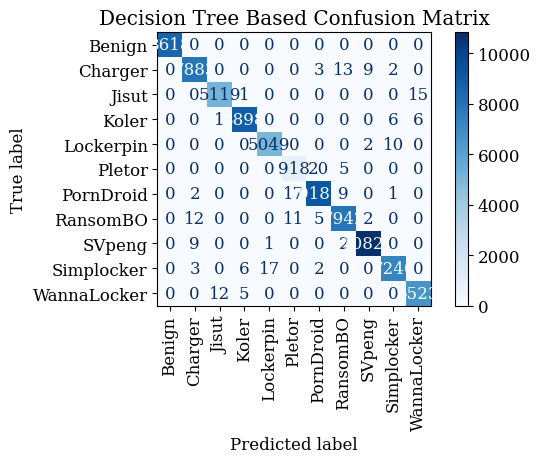

In [19]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X_train, y_train)
pred11 = dt1.predict(X_test)

accuracy = accuracy_score(y_test, pred11)
precision = precision_score(y_test, pred11, average='weighted', zero_division=0)
recall = recall_score(y_test, pred11, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred11, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")


cm = confusion_matrix(y_test, pred11)
ConfusionMatrixDisplay(cm, display_labels=dt1.classes_).plot(cmap='Blues', xticks_rotation=90)
plt.title('Decision Tree Based Confusion Matrix')
plt.tight_layout()
plt.show()

In [20]:
print(classification_report(y_test, pred11, zero_division=0, digits=3))

              precision    recall  f1-score   support

      Benign      1.000     1.000     1.000      8618
     Charger      0.997     0.997     0.997      7910
       Jisut      0.997     0.997     0.997      5135
       Koler      0.999     0.999     0.999      8911
   Lockerpin      0.996     0.998     0.997      5061
      Pletor      0.970     0.973     0.972       943
   PornDroid      0.997     0.997     0.997      9217
    RansomBO      0.996     0.996     0.996      7972
      SVpeng      0.999     0.999     0.999     10832
  Simplocker      0.997     0.996     0.997      7268
 WannaLocker      0.997     0.997     0.997      6540

    accuracy                          0.997     78407
   macro avg      0.995     0.995     0.995     78407
weighted avg      0.997     0.997     0.997     78407



Accuracy:  96.185%
Precision: 96.191%
Recall:    96.185%
F1 Score:  96.186%


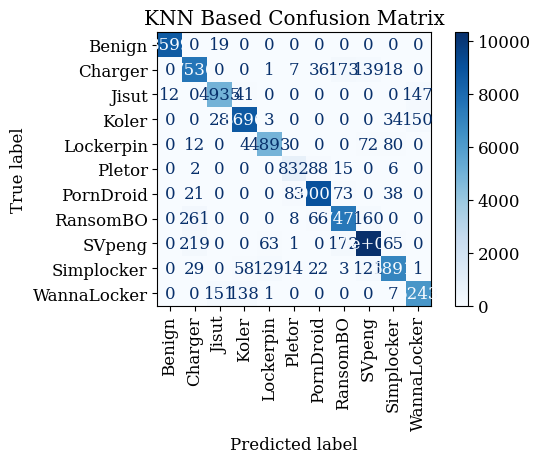

In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train, y_train)
pred22 = knn1.predict(X_test)

accuracy = accuracy_score(y_test, pred22)
precision = precision_score(y_test, pred22, average='weighted', zero_division=0)
recall = recall_score(y_test, pred22, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred22, average='weighted', zero_division=0)

print(f"Accuracy:  {accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")


cm = confusion_matrix(y_test, pred22)
ConfusionMatrixDisplay(cm, display_labels=knn1.classes_).plot(cmap='Blues', xticks_rotation=90)
plt.title('KNN Based Confusion Matrix')
plt.tight_layout()
plt.show()

In [22]:
print(classification_report(y_test, pred22, zero_division=0, digits=3))

              precision    recall  f1-score   support

      Benign      0.999     0.998     0.998      8618
     Charger      0.933     0.953     0.943      7910
       Jisut      0.961     0.961     0.961      5135
       Koler      0.973     0.976     0.974      8911
   Lockerpin      0.961     0.967     0.964      5061
      Pletor      0.880     0.882     0.881       943
   PornDroid      0.977     0.977     0.977      9217
    RansomBO      0.945     0.938     0.941      7972
      SVpeng      0.954     0.952     0.953     10832
  Simplocker      0.965     0.948     0.957      7268
 WannaLocker      0.954     0.955     0.955      6540

    accuracy                          0.962     78407
   macro avg      0.955     0.955     0.955     78407
weighted avg      0.962     0.962     0.962     78407



In [30]:
from sklearn.linear_model import LogisticRegression

#lr1 = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)
lr1 = LogisticRegression(solver='lbfgs', max_iter=1000)
lr1.fit(X_train, y_train)
pred33 = lr1.predict(X_test)

accuracy = accuracy_score(y_test, pred33)
precision = precision_score(y_test, pred33, average='weighted', zero_division=0)
recall = recall_score(y_test, pred33, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred33, average='weighted', zero_division=0)


print(f"Accuracy:  {accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")

if(accuracy <= 50):
    print("Accuracy is too poor to consider")
elif(accuracy > 50 and accuracy <90):
    print("Accuracy is still too poor")
else: 
    print("The model can be considered as a justified model for this dataset")



/root/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy:  38.113%
Precision: 33.888%
Recall:    38.113%
F1 Score:  32.121%
Accuracy is too poor to consider


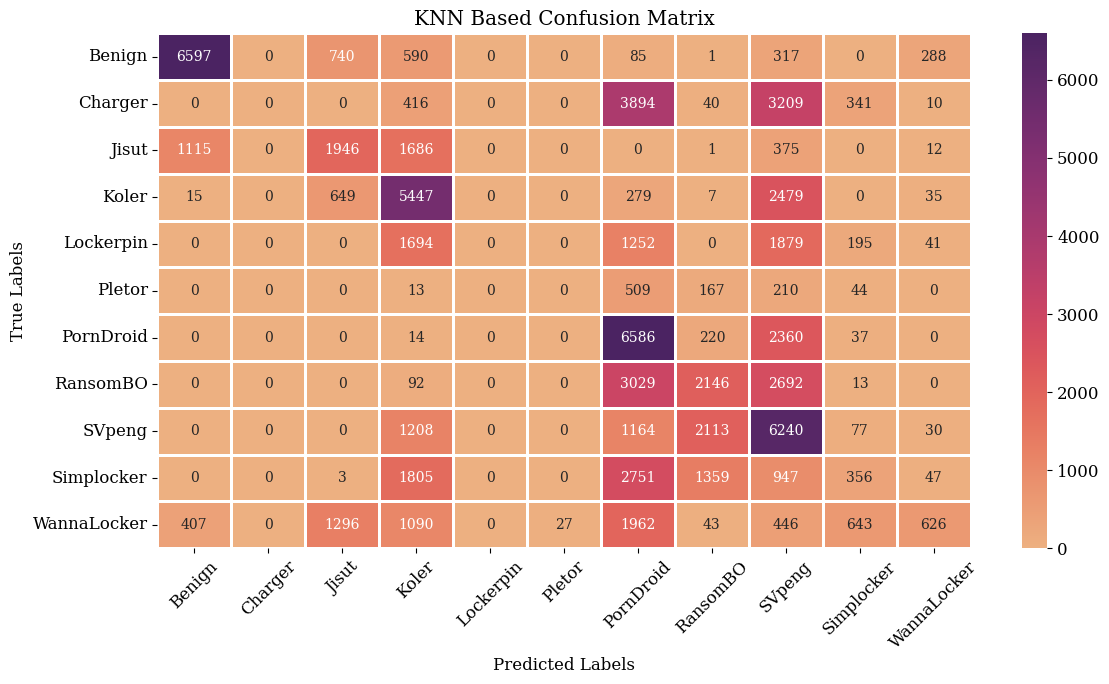

In [29]:
import seaborn as sns
cm = confusion_matrix(y_test, pred33)
cmap = sns.color_palette('flare', as_cmap=True)
class_labels = knn1.classes_

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True, ax=ax, annot_kws={'fontsize': 10}, linewidths=1, linecolor='white')
ax.set_title('KNN Based Confusion Matrix')
ax.set_xlabel('Predicted Labels')
ax.set_ylabel('True Labels')
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)
plt.tight_layout()
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=400, random_state=42)
rf.fit(X_train, y_train)
pred44 = rf.predict(X_test)

accuracy = accuracy_score(y_test, pred44)
precision = precision_score(y_test, pred44, average='weighted', zero_division=0)
recall = recall_score(y_test, pred44, average='weighted', zero_division=0)
f1 = f1_score(y_test, pred44, average='weighted', zero_division=0)


print(f"Accuracy:  {accuracy*100:.3f}%")
print(f"Precision: {precision*100:.3f}%")
print(f"Recall:    {recall*100:.3f}%")
print(f"F1 Score:  {f1*100:.3f}%")

Accuracy:  96.595%
Precision: 96.592%
Recall:    96.595%
F1 Score:  96.555%


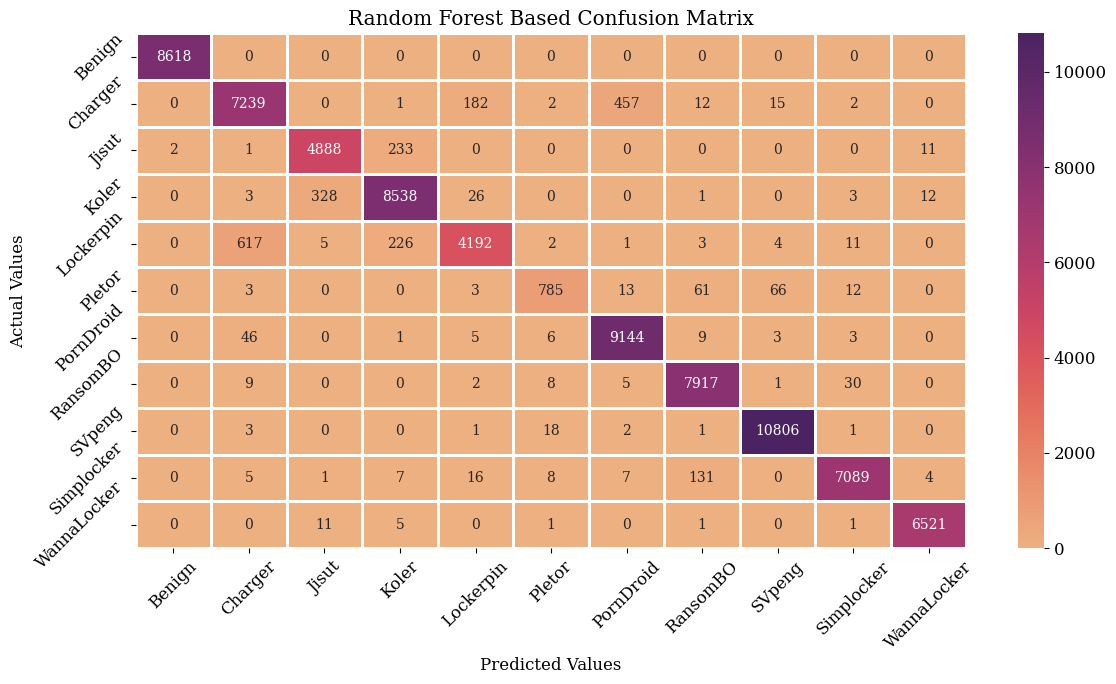

In [37]:
cm = confusion_matrix(y_test, pred44)
cmap = sns.color_palette('flare', as_cmap=True)
class_labels1 = rf.classes_

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True, ax=ax, annot_kws={'fontsize': 10}, linewidths=1, linecolor='white')

ax.set_title("Random Forest Based Confusion Matrix")
ax.set_xlabel("Predicted Values")
ax.set_ylabel("Actual Values")
ax.set_xticklabels(class_labels1, rotation=45)
ax.set_yticklabels(class_labels1, rotation=45)

plt.tight_layout()
plt.show()